# Financial Data Analysis with Python: Univariate & Multivariate Distributions



In [5]:
# Import essential libraries
import numpy as np  # Numerical computing
import matplotlib.pyplot as plt  # Visualization
from scipy.stats import norm, t, expon, gamma  # Statistical distributions
import pandas as pd  # Data handling


In [6]:

# ===========================================
# PART 1: UNIVARIATE DISTRIBUTIONS
# (From Seminar 2P1 pages 8-34)
# ===========================================

def plot_univariate_distributions():
    """
    Visualizes four key distributions from financial data:
    1. Normal (Gaussian) - Symmetric, thin tails
    2. Student's t - Fat-tailed (more extreme events)
    3. Exponential - Right-skewed (waiting times)
    4. Gamma - Flexible shape (insurance claims)

    Concepts covered:
    - PDF (Probability Density Function)
    - Skewness (asymmetry)
    - Kurtosis (tail thickness)
    """

    # Generate x values for plotting
    x = np.linspace(-5, 5, 1000)  # Symmetric range
    x_positive = np.linspace(0, 5, 1000)  # Positive-only range

    # Create figure with 4 subplots
    plt.figure(figsize=(12, 8))

    # ----------------------------
    # 1. Normal Distribution (Page 17-19)
    # ----------------------------
    plt.subplot(2, 2, 1)
    plt.plot(x, norm.pdf(x), 'b-', label='N(0,1)')
    plt.title("Normal Distribution\n(Symmetric, Mesokurtic)")
    plt.xlabel("x")
    plt.ylabel("Probability Density")
    plt.legend()

    # ----------------------------
    # 2. Student's t-Distribution (Pages 21-23)
    # ----------------------------
    plt.subplot(2, 2, 2)
    plt.plot(x, t.pdf(x, df=3), 'r-', label='t (df=3)')
    plt.plot(x, norm.pdf(x), 'b--', label='N(0,1)')
    plt.title("Student's t vs Normal\n(Note fatter tails)")
    plt.xlabel("x")
    plt.ylabel("Probability Density")
    plt.legend()

    # ----------------------------
    # 3. Exponential Distribution (Page 30)
    # ----------------------------
    plt.subplot(2, 2, 3)
    plt.plot(x_positive, expon.pdf(x_positive), 'g-', label='Exponential(1)')
    plt.title("Exponential Distribution\n(Right-skewed)")
    plt.xlabel("x")
    plt.ylabel("Probability Density")
    plt.legend()

    # ----------------------------
    # 4. Gamma Distribution (Page 28)
    # ----------------------------
    plt.subplot(2, 2, 4)
    plt.plot(x_positive, gamma.pdf(x_positive, a=2), 'm-', label='Gamma(2)')
    plt.plot(x_positive, gamma.pdf(x_positive, a=1), 'c-', label='Gamma(1)')
    plt.title("Gamma Distribution\n(Flexible shape)")
    plt.xlabel("x")
    plt.ylabel("Probability Density")
    plt.legend()

    plt.tight_layout()
    plt.show()

In [7]:
# ===========================================
# PART 2: MULTIVARIATE DISTRIBUTIONS
# (From Seminar 2P2 pages 18-32)
# ===========================================

def generate_bivariate_normal(correlation=0.7):
    """
    Generates and plots correlated normal variables
    demonstrating:
    - Covariance matrix (Page 12-14)
    - Joint distributions (Page 7-9)
    - Correlation vs independence (Page 10-11)

    Parameters:
    - correlation: Desired Pearson correlation (-1 to 1)
    """
    # Mean vector (both variables centered at 0)
    mean = [0, 0]

    # Covariance matrix (Page 13)
    cov = [[1, correlation],  # Var(X), Cov(X,Y)
           [correlation, 1]] # Cov(Y,X), Var(Y)

    # Generate data (Page 23)
    x, y = np.random.multivariate_normal(mean, cov, 1000).T

    # Plot with regression line
    plt.figure(figsize=(10, 6))
    plt.scatter(x, y, alpha=0.5, label='Data points')

    # Add regression line
    m, b = np.polyfit(x, y, 1)
    plt.plot(x, m*x + b, 'r-', label=f'Regression line (ρ={correlation:.2f})')

    plt.title("Bivariate Normal Distribution\n(Showing Linear Dependence)")
    plt.xlabel("X ~ N(0,1)")
    plt.ylabel("Y ~ N(0,1)")
    plt.legend()
    plt.grid(True)
    plt.show()

    return x, y

In [8]:
# ===========================================
# PART 3: DISTRIBUTION TESTING
# (From Seminar 2P1 pages 19, 22)
# ===========================================

def test_normality(data):
    """
    Tests if data follows normal distribution using:
    - Histogram with normal curve overlay
    - Q-Q plot (Quantile-Quantile)

    Concepts:
    - Goodness-of-fit testing
    - Visual diagnostics
    """
    plt.figure(figsize=(12, 5))

    # ----------------------------
    # 1. Histogram with Normal Fit
    # ----------------------------
    plt.subplot(1, 2, 1)
    plt.hist(data, bins=30, density=True, alpha=0.6, color='b', label='Data')

    # Fit normal distribution
    mu, std = norm.fit(data)
    xmin, xmax = plt.xlim()
    x = np.linspace(xmin, xmax, 100)
    p = norm.pdf(x, mu, std)
    plt.plot(x, p, 'k', linewidth=2, label=f'N(μ={mu:.2f}, σ={std:.2f})')
    plt.title("Histogram with Normal Fit")
    plt.xlabel("Value")
    plt.ylabel("Density")
    plt.legend()

    # ----------------------------
    # 2. Q-Q Plot (Page 19)
    # ----------------------------
    plt.subplot(1, 2, 2)
    from scipy.stats import probplot
    probplot(data, plot=plt)
    plt.title("Q-Q Plot\n(Deviation from line = non-normality)")

    plt.tight_layout()
    plt.show()


In [9]:
# ===========================================
# PART 4: RISK MEASUREMENT
# (From Seminar 2P1 Quiz questions)
# ===========================================

def calculate_risk_metrics(data, alpha=0.95):
    """
    Calculates and compares:
    - Value-at-Risk (VaR) - Worst loss at confidence level
    - Expected Shortfall (ES) - Average beyond VaR

    Parameters:
    - data: Array of losses/returns
    - alpha: Confidence level (0.95 for 95% VaR)
    """
    # Sort the data
    sorted_data = np.sort(data)

    # Value at Risk (Page 39-40)
    var_index = int(alpha * len(sorted_data))
    var = sorted_data[var_index]

    # Expected Shortfall (Page 44-46)
    tail_losses = [x for x in sorted_data if x >= var]
    es = np.mean(tail_losses)

    print(f"\nRisk Metrics at {alpha*100}% confidence:")
    print(f"- Value-at-Risk (VaR): {var:.4f}")
    print(f"- Expected Shortfall (ES): {es:.4f}")
    print(f"ES > VaR indicates tail risk")


=== Financial Data Analysis Project ===
Covering concepts from Seminars 2P1 & 2P2

1. Visualizing Univariate Distributions...


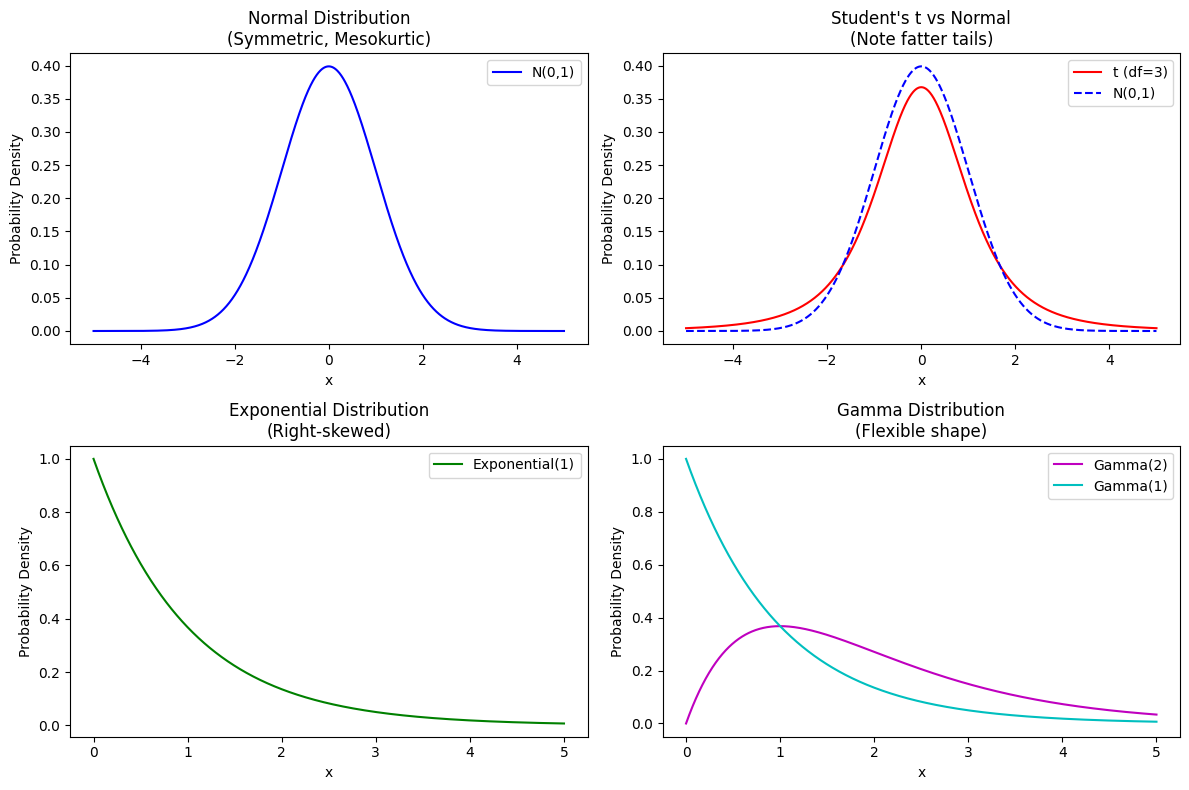


2. Generating Correlated Variables...


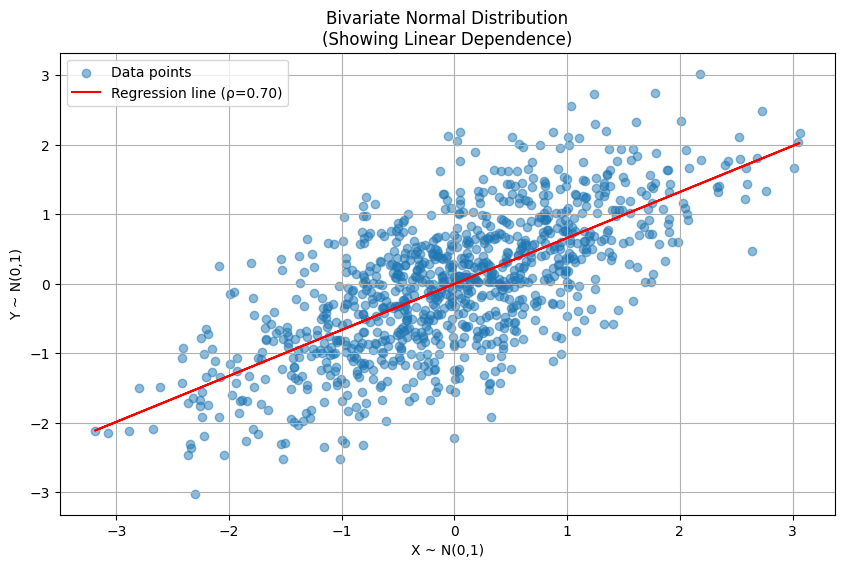


3. Testing Normality Assumption...


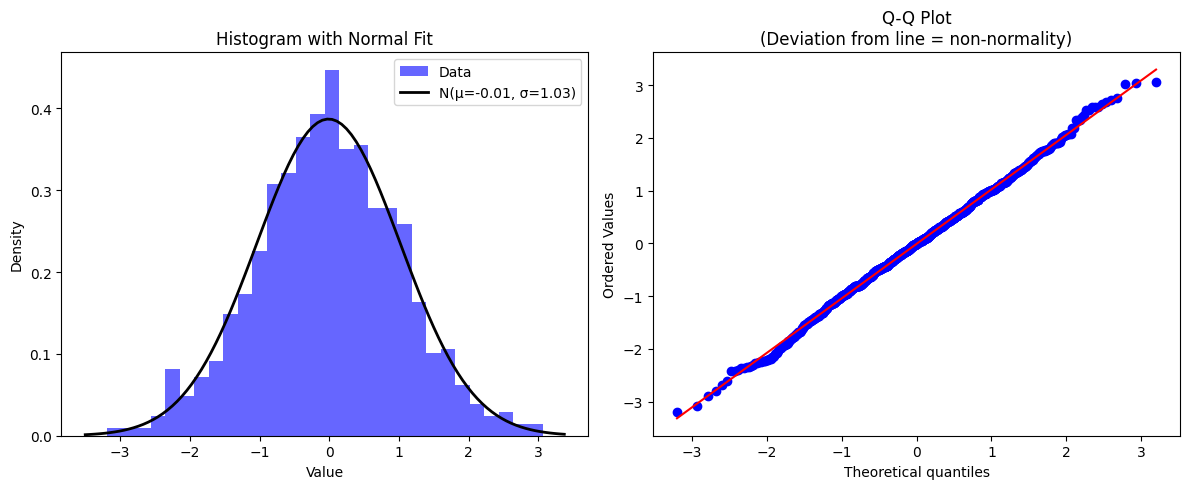


4. Calculating Risk Measures...

Risk Metrics at 95.0% confidence:
- Value-at-Risk (VaR): 1.3009
- Expected Shortfall (ES): 1.9986
ES > VaR indicates tail risk

Key Insights:
- Financial data often has fatter tails than normal
- Correlation ≠ causation in multivariate analysis
- Expected Shortfall better captures tail risk than VaR


In [10]:
# ===========================================
# MAIN DEMONSTRATION
# ===========================================

def main():
    print("=== Financial Data Analysis Project ===")
    print("Covering concepts from Seminars 2P1 & 2P2\n")

    # 1. Show univariate distributions
    print("1. Visualizing Univariate Distributions...")
    plot_univariate_distributions()

    # 2. Generate correlated normal data
    print("\n2. Generating Correlated Variables...")
    x, y = generate_bivariate_normal(correlation=0.7)

    # 3. Test normality
    print("\n3. Testing Normality Assumption...")
    test_normality(x)

    # 4. Compare risk metrics
    print("\n4. Calculating Risk Measures...")

    # Generate heavy-tailed data (more realistic for finance)
    heavy_tailed_data = np.random.standard_t(df=3, size=10000) * 0.5 + 0.1

    calculate_risk_metrics(heavy_tailed_data)

    print("\nKey Insights:")
    print("- Financial data often has fatter tails than normal")
    print("- Correlation ≠ causation in multivariate analysis")
    print("- Expected Shortfall better captures tail risk than VaR")

if __name__ == "__main__":
    main()